# Function Transformer

------------------------------------------------------------------------------------
A `FunctionTransformer` is a wrapper around a Python function. Instead of writing a completely new transforer class, sklearn lets us wrap any Python function

# Why do we need it?

------------------------------------------------------------------------------------
Suppose we have salaries: `1000, 2000, 3000...`. Machine learning algorithms often work better with `log(salaries)`, etc. but pipeline cannot implement this, pipeline only accepts sklearn transformers. So we wrap it

In [2]:
import numpy as np
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log1p)

## The Syntax

In [ ]:
FunctionTransformer(
    func = None,
    inverse_func = None,
    validate = False,
    feature_names_out=None
)

## Important Parameters

In [ ]:
# parameter 1: func

# this is the function you want to apply
FunctionTransformer(np.log1p)  # every value becomes: log(x + 1)

# another example
FunctionTransformer(np.sqrt) # every value becomes: √x

# another example
FunctionTransformer(np.square) # every value becomes: x²

In [ ]:
# parameter 2: inverse_func

# suppose you transform x into log(x), later you want the original values back
# original value --> log() --> exp()

FunctionTransformer(
    func=np.log10,
    inverse_func=expm1
)

In [ ]:
# parameter 3: validate

x = [1,2,3,4] # Python list

# but sklearn likes NumPy Array: 2D
# when:
validate = True

# sklearn checks:
    # input shape
    # converts to array
    # verifies dimension

# when:
validate = False

# no checking
# validate = False is the default and is usually recommended because it avoids unnecessary input checing, making code faster and more flexible


## Example

In [8]:
transformer = FunctionTransformer(np.log1p)

X = np.array([[1],
              [10],
              [100]])

X_transformed = transformer.fit_transform(X)
X_transformed

array([[0.69314718],
       [2.39789527],
       [4.61512052]])

In [10]:
def square(x):
    return x**2

transformer = FunctionTransformer(square)

X = np.array([[2],
              [3],
              [4]])

X_transformed = transformer.fit_transform(X)
X_transformed

array([[ 4],
       [ 9],
       [16]])

In [11]:
def multiply(x):
    return x*10

transformer = FunctionTransformer(multiply)

X = np.array([[5],
              [7],
              [10]])

X_transformed = transformer.fit_transform(X)
X_transformed

array([[ 50],
       [ 70],
       [100]])

In [12]:
def c_to_f(x):
    return (x*(9/5)+32)

transformer = FunctionTransformer(c_to_f)

X = np.array([[20],
              [30],
             ])

X_transformed = transformer.fit_transform(X)
X_transformed

array([[68.],
       [86.]])

## Using it inside Pipeline

In [ ]:
pipeline = Pipeline([
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler()),
    ('model', LinearRgeression())
])

## Using it insdie Column Transformer

In [ ]:
ColumnTransformer(transformers=[
    ('log_income', FunctionTransformer(np.log1p)), ['Income']
])

## When should you use FunctionTransformer?

---------------------------------------------------------------------------------
Use it when you need to:
* apply a log transformation
* apply square root or square transformations
* create custom features (e.g., BMI)
* convert units (Celsius ↔ Fahrenheit, inches ↔ centimeters)
* apply mathematical operations like clipping or normalizing that aren't provided by built-in transformers
* integrate custom preprocessing cleanly into a `Pipeline` or `ColumnTransformer`


## When should NOT use it?

---------------------------------------------------------------------------------
Do not use `FunctionTransformer` when your transformation needs to  `learn from the traing data`  

`Examples`:  
* `StandardScaler` learns the mean and standard deviation
* `MinMaxScaler` learns the minimum and maximum
* `SimpleImputer` learns the fill values
* `PCA` learns the principle components

If your transformation requires a `fit()` step to compute parameters, you should create a **custom transformer** by inheriting from `BaseEstimator` and `TransformerMixin` instead of using `FunctionTransformer`

In [99]:
import numpy as np
import pandas as pd 

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

In [100]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)

df["Price"] = housing.target


df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [101]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price'],
      dtype='object')

In [102]:
# separate features and target
X = df.drop(columns="Price")
y = df["Price"]

In [103]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [104]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512, 8)
(4128, 8)
(16512,)
(4128,)


In [105]:
X_train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80


In [106]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 14196 to 15795
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      16512 non-null  float64
 1   HouseAge    16512 non-null  float64
 2   AveRooms    16512 non-null  float64
 3   AveBedrms   16512 non-null  float64
 4   Population  16512 non-null  float64
 5   AveOccup    16512 non-null  float64
 6   Latitude    16512 non-null  float64
 7   Longitude   16512 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB


In [107]:
X_train.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [108]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,16512.0,3.880754,1.904294,0.499900,2.566700,3.545800,4.773175,15.000100
HouseAge,16512.0,28.608285,12.602499,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,16512.0,5.435235,2.387375,0.888889,4.452055,5.235874,6.061037,141.909091
AveBedrms,16512.0,1.096685,0.433215,0.333333,1.006508,1.049286,1.100348,25.636364
Population,16512.0,1426.453004,1137.056380,3.000000,789.000000,1167.000000,1726.000000,35682.000000
AveOccup,16512.0,3.096961,11.578744,0.692308,2.428799,2.817240,3.280000,1243.333333
Latitude,16512.0,35.643149,2.136665,32.550000,33.930000,34.260000,37.720000,41.950000
Longitude,16512.0,-119.582290,2.005654,-124.350000,-121.810000,-118.510000,-118.010000,-114.310000


In [109]:
X_train.duplicated().sum()

np.int64(0)

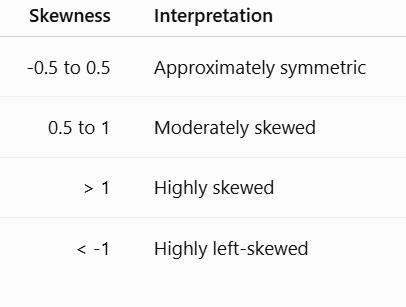

In [110]:
skewness = X_train.skew()

print(skewness.sort_values(ascending=False))

AveOccup      88.052663
AveBedrms     23.170746
AveRooms      18.607090
Population     5.276131
MedInc         1.634090
Latitude       0.461504
HouseAge       0.063453
Longitude     -0.288418
dtype: float64


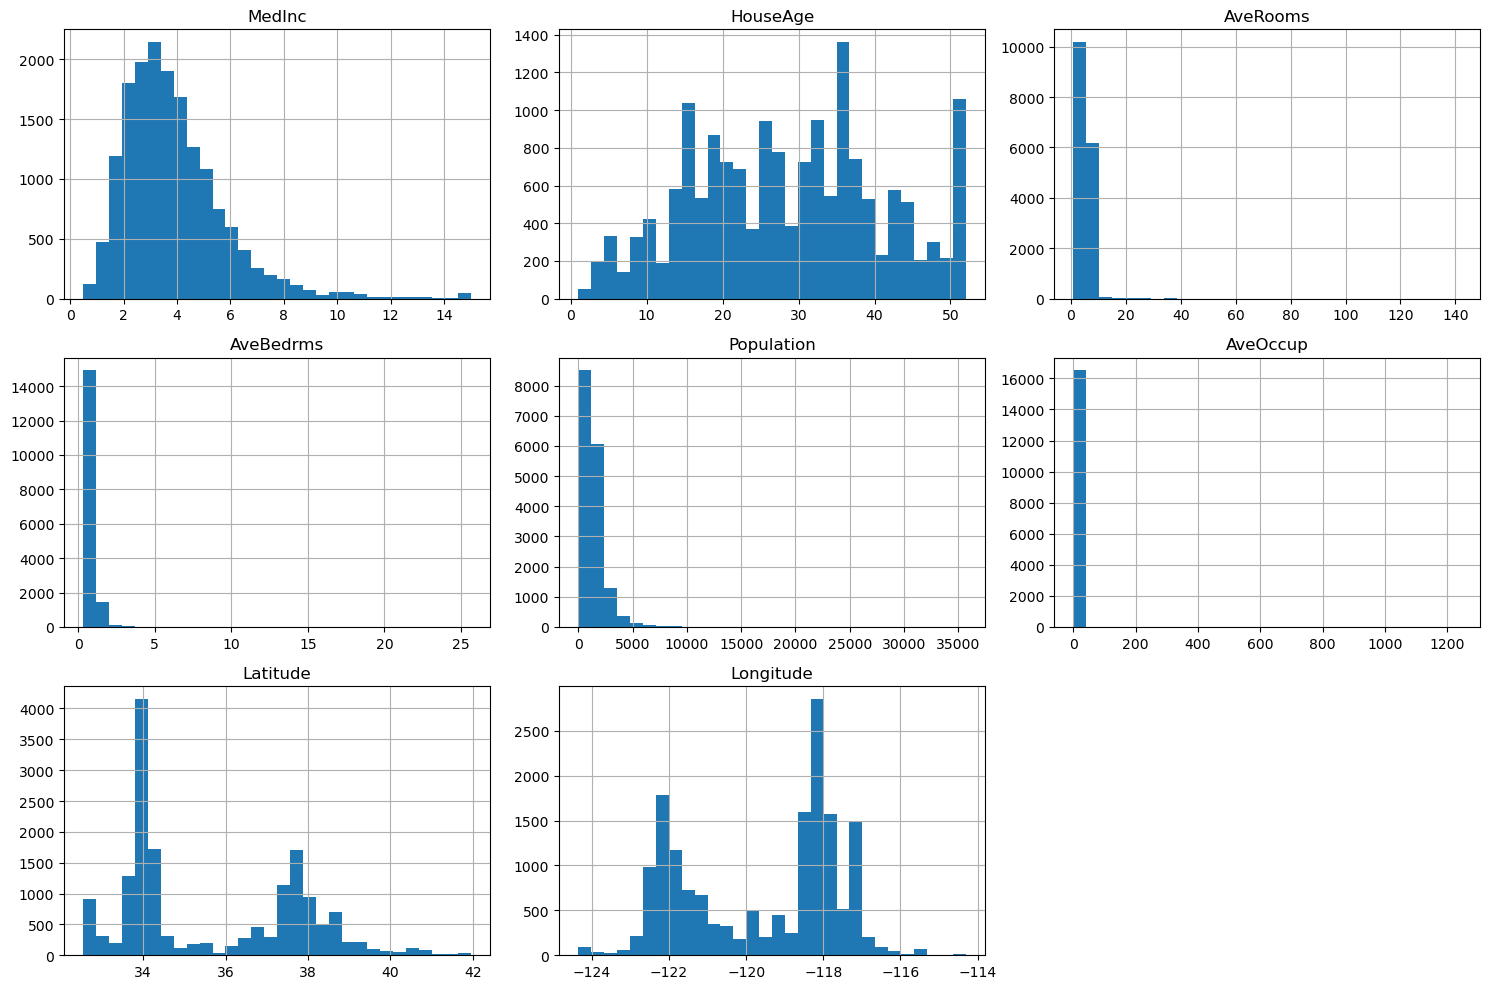

In [111]:
import matplotlib.pyplot as plt

X_train.hist(
    figsize=(15, 10),
    bins=30
)

plt.tight_layout()
plt.show()

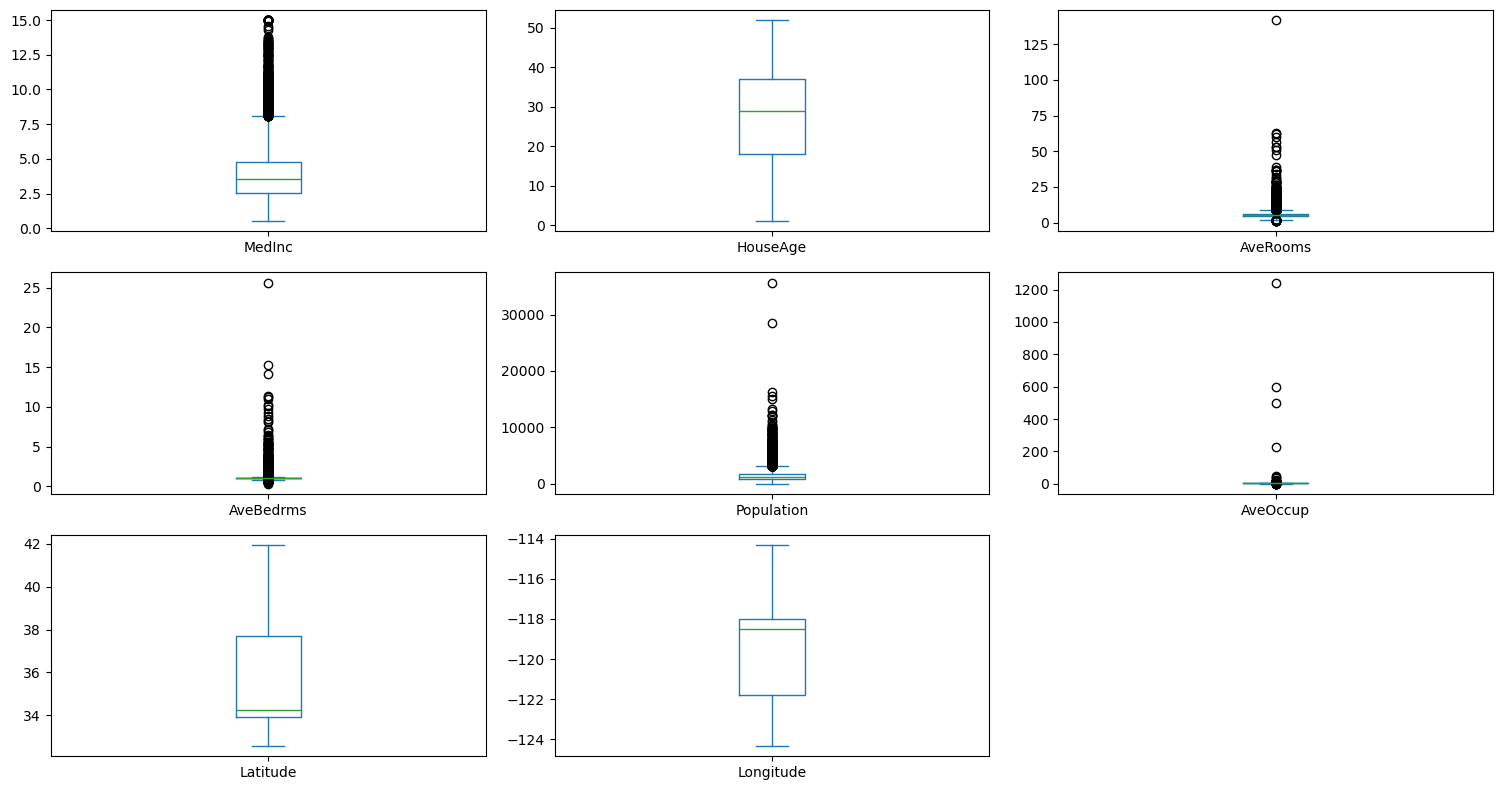

In [112]:
X_train.plot(kind='box', subplots=True, layout=(3,3), figsize=(15,8))

plt.tight_layout()
plt.show()

In [113]:
Q1 = X_train["MedInc"].quantile(0.25)
Q3 = X_train["MedInc"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower)
print(upper)

-0.7430125000000003
8.0828875


In [114]:
outliers = X_train[
    (X_train["MedInc"] < lower) |
    (X_train["MedInc"] > upper)
]

print(outliers.shape)

(529, 8)


In [116]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

from sklearn.linear_model import LinearRegression

In [117]:
log_pipeline = Pipeline([
    ('log', FunctionTransformer(np.log1p, validate=False))
])

In [118]:
preprocessor = ColumnTransformer(transformers=[
   ( 'log_transformer', log_pipeline, ['MedInc'])
], remainder='passthrough')

In [119]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [120]:
pipeline.fit(X_train, y_train)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('log_transformer',
                                                  Pipeline(steps=[('log',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>))]),
                                                  ['MedInc'])])),
                ('regressor', LinearRegression())])

In [122]:
y_pred = pipeline.predict(X_test)

In [129]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred) # lower is better
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error", mae)
print("Root Mean Squared Error", rmse)
print("R-squared Score", r2)

Mean Absolute Error 0.566385615179267
Root Mean Squared Error 0.7692965164067366
R-squared Score 0.5483721952592244


In [131]:
results = pd.DataFrame({
    'Actual':y_test,
    'Predicted':y_pred
})

results.sample(10)

,Actual,Predicted
6451,5.00001,2.724918
9665,0.52600,-0.609816
621,1.83300,2.587260
14214,1.13500,1.634858
18380,5.00001,3.803532
6301,1.33300,1.816005
20099,0.79400,0.260180
7513,1.11900,2.538712
16238,0.98300,2.291149
2380,0.69300,0.886550


In [132]:
residuals = y_test - y_pred
residuals

20046   -0.005340
3024    -1.310877
15663    2.181417
20484   -0.708252
9814     0.019186
           ...   
15362    0.470132
16623    0.368130
18086    1.065642
2144    -0.551875
3665    -0.593400
Name: Price, Length: 4128, dtype: float64

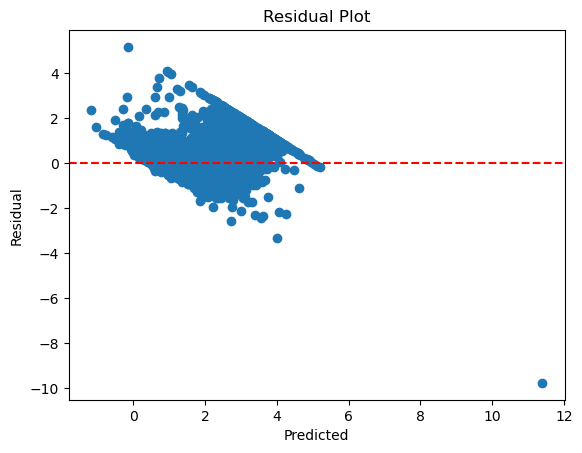

In [133]:
plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

#### Without Log-transformation

In [134]:
baseline_preprocessor = ColumnTransformer(
    transformers=[],
    remainder="passthrough"
)

baseline_pipeline = Pipeline([
    ("preprocessor", baseline_preprocessor),
    ("regressor", LinearRegression())
])

In [135]:
baseline_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough', transformers=[])),
                ('regressor', LinearRegression())])

In [136]:
baseline_pred = baseline_pipeline.predict(X_test)

In [137]:
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

In [139]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Log Transformation"
    ],
    "MAE": [
        baseline_mae,
        mae
    ],
    "RMSE": [
        baseline_rmse,
        rmse
    ],
    "R²": [
        baseline_r2,
        r2
    ]
})

comparison

,Model,MAE,RMSE,R²
0,Baseline,0.533200,0.745581,0.575788
1,Log Transformation,0.566386,0.769297,0.548372
